Прогнозування кількості відвідувачів кафе залежно від температури та рекламного бюджету.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [52]:
np.random.seed(42)

n_samples = 120  


temperature = np.random.uniform(0, 35, n_samples)        
advert_budget = np.random.uniform(0, 1000, n_samples)    



visitors = 20 + 2*temperature + 0.05*advert_budget + np.random.normal(0, 5, n_samples)

df_cafe = pd.DataFrame({
    'Temperature': temperature,
    'Advert_Budget': advert_budget,
    'Visitors': visitors
})

print(df_cafe.head())


   Temperature  Advert_Budget    Visitors
0    13.108904     807.440155   85.472502
1    33.275001     896.091300  134.924569
2    25.619788     318.003475   89.505938
3    20.953047     110.051925   67.044546
4     5.460652     227.935163   38.084094


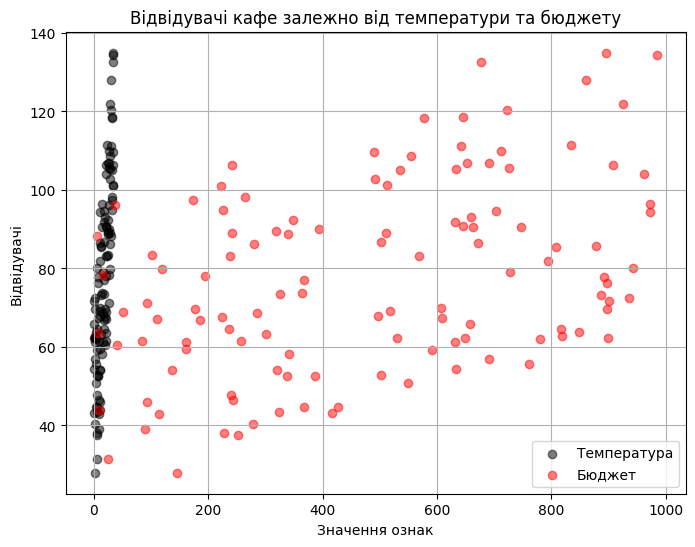

In [53]:
plt.figure(figsize=(8,6))
plt.scatter(df_cafe['Temperature'], df_cafe['Visitors'], c='black', alpha=0.5, label='Температура')
plt.scatter(df_cafe['Advert_Budget'], df_cafe['Visitors'], c='red', alpha=0.5, label='Бюджет')
plt.xlabel('Значення ознак')
plt.ylabel('Відвідувачі')
plt.title('Відвідувачі кафе залежно від температури та бюджету')
plt.legend()
plt.grid(True)
plt.show()


In [54]:

X = df_cafe[['Temperature', 'Advert_Budget']]


y = df_cafe['Visitors']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}, MAE: {mae:.2f}, R^2: {r2:.2f}')


MSE: 22.22, MAE: 3.62, R^2: 0.96


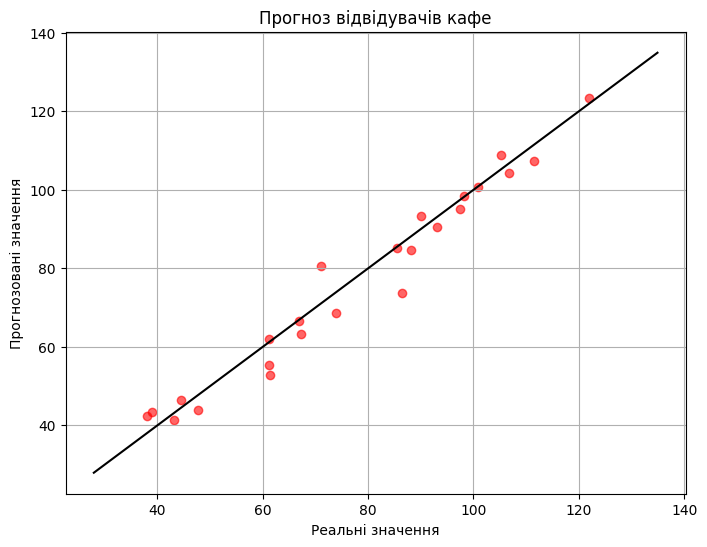

In [55]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='red', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='black') 
plt.xlabel('Реальні значення')
plt.ylabel('Прогнозовані значення')
plt.title('Прогноз відвідувачів кафе')
plt.grid(True)
plt.show()
